<div style="padding: 10px; border-left: 6px solid #28a745; background-color: #d4edda; color: #155724;">
<strong>Success!</strong> Your model trained successfully.
</div>


<div style="padding: 10px; border-left: 6px solid #ffc107; background-color: #fff3cd; color: #856404;">
<strong>Warning!</strong> You have missing values in your dataset.
</div>


<div style="padding: 10px; border-left: 6px solid #17a2b8; background-color: #d1ecf1; color: #0c5460;">
<strong>Note:</strong> You can skip this step if using default settings.
</div>


<div style="padding: 10px; border-left: 6px solid #dc3545; background-color: #f8d7da; color: #721c24;">
<strong>Error!</strong> Failed to load the data file.
</div>


## 01- Model

<div style="text-align: center">
  <img src="./transformer_1.png" alt="Sample Image" width=300 height=400/>
</div>


In [1]:
import torch
import torch.nn as nn
import math

#### Input Embedding

In [ ]:
class InputEmbedding(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__() # Initialize the parent class
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model) # This creates a matrix of shape (vocab_size, d_model)

    def forward(self, x):
        #  In the embedding layers, we multiply those weights by sqrt(d_model) 
        # This was mentioned in the attention research paper
        return self.embedding(x) * math.sqrt(self.d_model)

#### Positional Encoding

$$
\begin{aligned}
\text{For even positions: } &\quad \text{PE}(pos, 2i) = \sin\left( \frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}} \right) \\
\text{For odd positions: } &\quad \text{PE}(pos, 2i+1) = \cos\left( \frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}} \right)
\end{aligned}
$$

$$
10000^{\frac{2i}{d_{\text{model}}}} = \exp\left( \frac{2i}{d_{\text{model}}} \cdot \log(10000) \right)
$$


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model:int, seq_len:int, dropout:float) -> None:
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)
        
        # creting a tensor of zeros with shape (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model)
        # creating a tensor of positions with shape (seq_len, 1)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        # this is the dinominator for the positional encoding formula
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        # Even positions - Apply sine function
        pe[:, 0::2] = torch.sin(position * div_term)
        # Odd positions - Apply cosine function
        pe[:, 1::2] = torch.cos(position * div_term)

        # Adding a new dimension to the tensor for batch processing
        pe = pe.unsqueeze(0)
        # Registering the positional encoding as a buffer so it is not a model parameter
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + (self.pe[:, :x.size(1)]).requires_grad_(False)
        return self.dropout(x)

In [ ]:
print("InputEmbedding and PositionalEncoding classes defined successfully.")

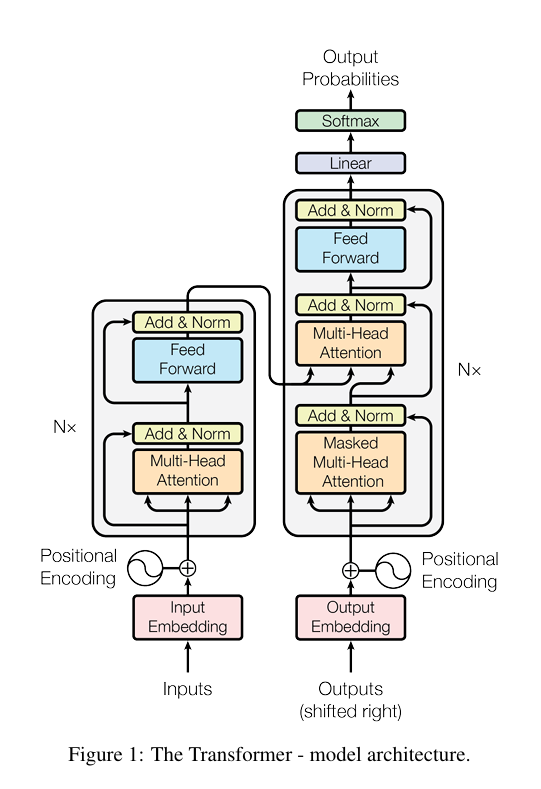